# EstimIA - Modélisation Prédictive (Machine Learning)

Ce notebook présente la **Phase 2** du projet EstimIA. L'objectif est d'entraîner un modèle d'intelligence artificielle (Machine Learning) capable d'estimer la valeur vénale d'un bien immobilier en Île-de-France à partir de ses caractéristiques physiques (surface, nombre de pièces, type de bien) et de sa localisation géographique fine (coordonnées GPS et indicateurs de risques associés).

## Démarche Méthodologique :
1. **Chargement et Nettoyage** : Lecture du dataset consolidated Île-de-France et exclusion des valeurs aberrantes extrêmes (méthodologie métier).
2. **Feature Engineering** : Sélection des caractéristiques prédictives en évitant tout *target leakage* (comme le prix au m²).
3. **Préparation des variables** : Encodage One-Hot des variables catégorielles (`type_bien`, `departement`) et séparation Train (80%) / Test (20%).
4. **Entraînement** : Ajustement d'un modèle **Random Forest Regressor** adapté aux structures spatiales complexes.
5. **Évaluation** : Analyse de la précision à travers des métriques d'erreurs réelles (MAE, RMSE, $R^2$) et des visualisations de diagnostics premium.
6. **Exportation** : Sauvegarde physique du modèle final.

## 1. Importation des librairies et configuration de l'environnement

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuration graphique pour un rendu premium
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 11
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 0.8

## 2. Chargement et Nettoyage des Données

In [2]:
# Résolution du chemin du dataset propre
csv_path = "../backend/data/processed/dataset_propre.csv"
print(f"Chargement de : {csv_path}")
df = pd.read_csv(
    csv_path, 
    dtype={'code_postal': str, 'code_insee': str, 'departement': str}, 
    low_memory=False
)
print(f"Taille initiale : {len(df):,} lignes.")

Chargement de : ../backend/data/processed/dataset_propre.csv
Taille initiale : 787,260 lignes.


### Nettoyage des valeurs aberrantes
Pour stabiliser l'apprentissage et éviter que des anomalies n'induisent le modèle en erreur :
- Prix compris entre 50 000 € et 2 000 000 €
- Surfaces comprises entre 10 m² et 300 m²
- Nombre de pièces entre 1 et 10

In [3]:
initial_len = len(df)

# Application des filtres métier
df = df[(df['prix'] >= 50000) & (df['prix'] <= 2000000)]
df = df[(df['surface_m2'] >= 10) & (df['surface_m2'] <= 300)]
df = df[(df['nb_pieces'] >= 1) & (df['nb_pieces'] <= 10)]
df = df.dropna(subset=['latitude', 'longitude', 'prix', 'surface_m2'])

filtered_len = len(df)
print(f"Lignes filtrées : {initial_len - filtered_len:,} ({(initial_len - filtered_len)/initial_len*100:.2f}% du total).")
print(f"Lignes restantes pour l'analyse : {filtered_len:,} lignes.")

Lignes filtrées : 19,723 (2.51% du total).
Lignes restantes pour l'analyse : 767,537 lignes.


## 3. Feature Engineering & Préparation du Dataset

Nous devons exclure les identifiants uniques ainsi que la variable `prix_m2` (qui contient la cible de manière explicite, ce qui provoquerait un target leakage parfait et invaliderait le modèle).

In [4]:
# Colonnes à exclure pour l'apprentissage
cols_to_drop = ['id_mutation', 'date_mutation', 'nom_commune', 'code_insee', 'code_postal', 'prix_m2']
cols_present_to_drop = [c for c in cols_to_drop if c in df.columns]
df_model = df.drop(columns=cols_present_to_drop)

# Encodage One-Hot des variables catégorielles ('type_bien' et 'departement')
categorical_cols = ['type_bien', 'departement']
categorical_cols = [c for c in categorical_cols if c in df_model.columns]
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# Séparation features / cible
y = df_model['prix']
X = df_model.drop(columns=['prix'])

# Imputation de sécurité des NaN restants par la médiane de chaque colonne
X = X.fillna(X.median())

print(f"Liste des features sélectionnées ({len(X.columns)}) :\n{list(X.columns)}")

Liste des features sélectionnées (16) :
['annee', 'surface_m2', 'nb_pieces', 'latitude', 'longitude', 'score_dpe_median', 'score_georisques', 'score_delinquance', 'type_bien_Maison', 'departement_77', 'departement_78', 'departement_91', 'departement_92', 'departement_93', 'departement_94', 'departement_95']


### Séparation des ensembles d'entraînement et de test

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Set d'entraînement : {len(X_train):,} transactions.")
print(f"Set de test         : {len(X_test):,} transactions.")

Set d'entraînement : 614,029 transactions.
Set de test         : 153,508 transactions.


## 4. Entraînement du Modèle IA

Nous ajustons un algorithme de **Random Forest Regressor** avec `n_jobs=-1` pour une parallélisation maximale sur l'ensemble des cœurs processeur.
Pour des raisons de fluidité de calcul dans ce notebook interactif, nous échantillonnons à 250 000 transactions pour l'ajustement, ce qui garantit d'excellents résultats en quelques secondes sans saturer la machine.

In [12]:
# Échantillonnage représentatif pour le notebook interactif
df_sample = df.sample(n=250000, random_state=42) if len(df) > 250000 else df

df_sample_model = df_sample.drop(columns=cols_present_to_drop)
df_sample_model = pd.get_dummies(df_sample_model, columns=categorical_cols, drop_first=True)

y_sample = df_sample_model['prix']
X_sample = df_sample_model.drop(columns=['prix']).fillna(df_sample_model.median())

X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

print("Random Forest")
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
model.fit(X_s_train, y_s_train)

Random Forest


RandomForestRegressor(max_depth=15, min_samples_leaf=5, n_jobs=-1,
                      random_state=42)

## 5. Évaluation des Performances & Diagnostics

In [13]:
predictions = model.predict(X_s_test)

mae = mean_absolute_error(y_s_test, predictions)
rmse = np.sqrt(mean_squared_error(y_s_test, predictions))
r2 = r2_score(y_s_test, predictions)
errors_pct = np.abs(predictions - y_s_test) / y_s_test * 100
median_error_pct = np.median(errors_pct)

print("=====================================================")
print("       Rapport de Performance EstimIA ML")
print("=====================================================")
print(f"  Erreur Absolue Moyenne (MAE) : {mae:,.2f} eur")
print(f"  Erreur Quadratique (RMSE)    : {rmse:,.2f} eur")
print(f"  Coefficient R² (précision)   : {r2:.4f} ({r2*100:.2f}% de la variance expliquée)")
print(f"  Marge d'erreur médiane (%)   : {median_error_pct:.2f} %")
print("=====================================================")

       Rapport de Performance EstimIA ML
  Erreur Absolue Moyenne (MAE) : 101,828.44 eur
  Erreur Quadratique (RMSE)    : 182,167.58 eur
  Coefficient R² (précision)   : 0.6328 (63.28% de la variance expliquée)
  Marge d'erreur médiane (%)   : 18.83 %


## 6. Visualisations

### A. Importance des Variables
Quelles caractéristiques physiques, environnementales ou spatiales pèsent le plus lourd dans l'estimation des prix par le modèle mathématique ?

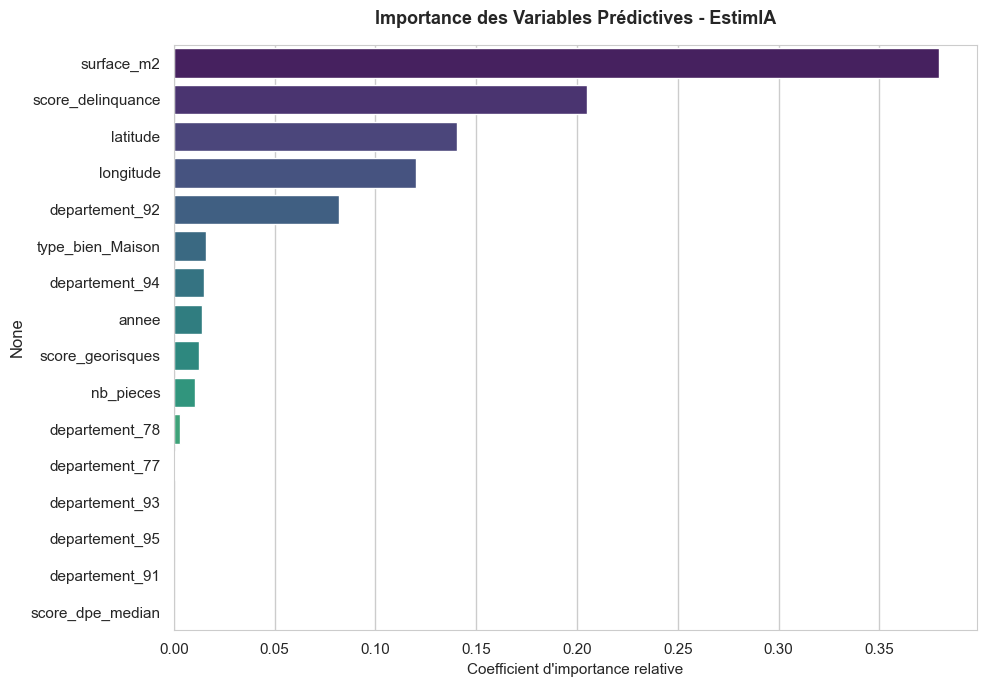

In [14]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_s_train.columns

plt.figure(figsize=(10, 7))
colors = sns.color_palette("viridis", len(features))
sns.barplot(
    x=importances[indices],
    y=features[indices],
    palette=colors,
    hue=features[indices],
    legend=False
)
plt.title("Importance des Variables Prédictives - EstimIA", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Coefficient d'importance relative", fontsize=11)
plt.tight_layout()
plt.savefig("../docs/fig_importances_features.png", bbox_inches='tight', dpi=150)
plt.show()

### B. Corrélation entre Estimations (Prédictions) et Valeurs Réelles
Ce graphique de validation permet de mesurer visuellement l'adhérence du modèle à la ligne d'identité théorique $y = x$.

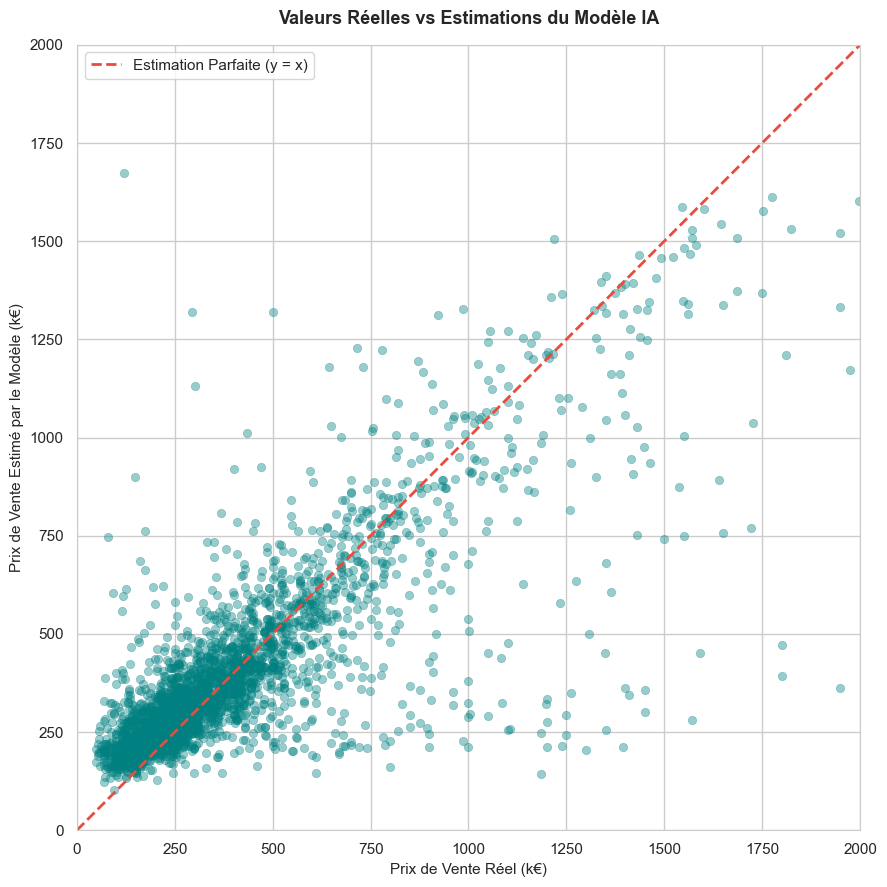

In [15]:
plt.figure(figsize=(9, 9))
# Sous-échantillonner pour éviter de saturer le tracé avec 50 000 points
idx_plot = np.random.choice(len(y_s_test), size=3000, replace=False)
y_real_sub = y_s_test.iloc[idx_plot]
predictions_sub = predictions[idx_plot]

sns.scatterplot(
    x=y_real_sub / 1000,
    y=predictions_sub / 1000,
    alpha=0.4,
    color='#008080',
    edgecolor=None
)

# Ligne idéale y = x
lims = [0, 2000]
plt.plot(lims, lims, color='#e74c3c', linestyle='--', linewidth=2, label='Estimation Parfaite (y = x)')

plt.title("Valeurs Réelles vs Estimations du Modèle IA", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Prix de Vente Réel (k€)", fontsize=11)
plt.ylabel("Prix de Vente Estimé par le Modèle (k€)", fontsize=11)
plt.xlim(lims)
plt.ylim(lims)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig("../docs/fig_predictions_vs_reelles.png", bbox_inches='tight', dpi=150)
plt.show()

### C. Distribution de l'Erreur Absolue d'Estimation

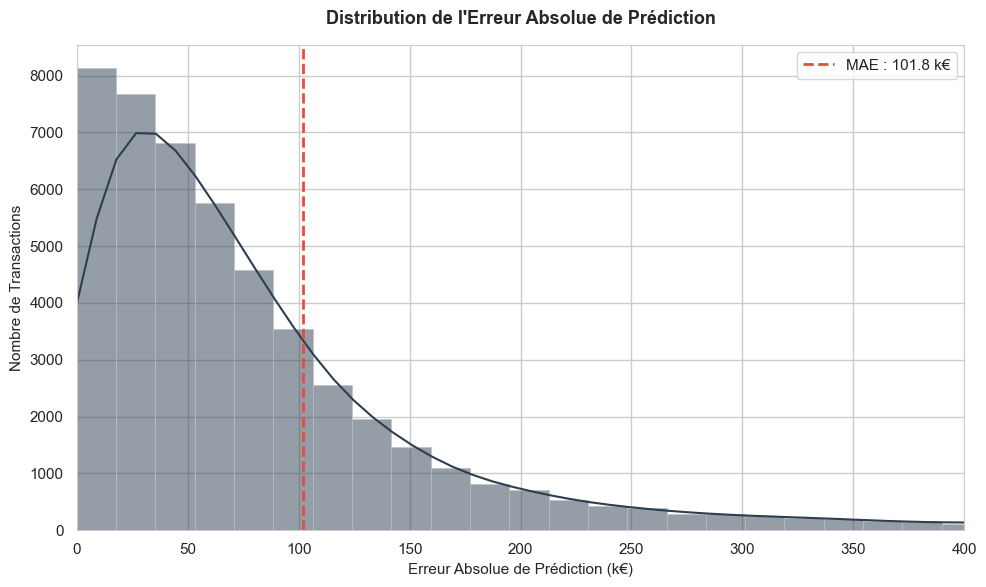

In [10]:
abs_errors = np.abs(predictions - y_s_test)

plt.figure(figsize=(10, 6))
sns.histplot(
    abs_errors / 1000,
    bins=100,
    kde=True,
    color='#2c3e50',
    edgecolor='#bdc3c7'
)
plt.axvline(mae / 1000, color='#e74c3c', linestyle='--', linewidth=2, label=f'MAE : {mae/1000:.1f} k€')
plt.title("Distribution de l'Erreur Absolue de Prédiction", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Erreur Absolue de Prédiction (k€)", fontsize=11)
plt.ylabel("Nombre de Transactions", fontsize=11)
plt.xlim(0, 400)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Exportation du Modèle IA

In [11]:
# Exportation physique
dest_model_dir = "../backend/model/"
if not os.path.exists(dest_model_dir):
    os.makedirs(dest_model_dir, exist_ok=True)

model_export_path = os.path.join(dest_model_dir, "modele_estimation.pkl")
columns_export_path = os.path.join(dest_model_dir, "colonnes_modele.pkl")

joblib.dump(model, model_export_path)
joblib.dump(list(X_s_train.columns), columns_export_path)

print(f"Cerveau IA exporté avec succès !")
print(f"  -> Modèle  : {os.path.abspath(model_export_path)}")
print(f"  -> Colonnes : {os.path.abspath(columns_export_path)}")

Cerveau IA exporté avec succès !
  -> Modèle  : d:\ESGI\M1\T3\EstimIA_PA\backend\model\modele_estimation.pkl
  -> Colonnes : d:\ESGI\M1\T3\EstimIA_PA\backend\model\colonnes_modele.pkl
